<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [30]:
# Your code here
df= pd.read_csv('./College.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: './College.csv'

In [ ]:
df.rename(columns={df.columns[0]: 'College'}, inplace=True)

df.head()

#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [ ]:
# Your code here
df.shape

In [ ]:
df.dtypes

In [31]:
df.isnull().sum()

College              0
Private              0
Apps                 0
Accept               0
Enroll               0
Top10perc            0
Top25perc            0
F.Undergrad          0
P.Undergrad          0
Outstate             0
Room.Board           0
Books                0
Personal             0
PhD                  0
Terminal             0
S.F.Ratio            0
perc.alumni          0
Expend               0
Grad.Rate            0
Apps_trans           0
Accept_trans         0
Enroll_trans         0
Top10perc_trans      0
F.Undergrad_trans    0
P.Undergrad_trans    0
Outstate_trans       0
Books_trans          0
Personal_trans       0
PhD_trans            0
Terminal_trans       0
S.F.Ratio_trans      0
perc.alumni_trans    0
Expend_trans         0
Apps_trans           0
Accept_trans         0
Enroll_trans         0
Top10perc_trans      0
F.Undergrad_trans    0
P.Undergrad_trans    0
Outstate_trans       0
Books_trans          0
Personal_trans       0
PhD_trans            0
Terminal_tr

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [32]:
# Your code here
df['PhD'].value_counts()


PhD
75.0    51
77.0    26
73.0    24
90.0    22
71.0    21
        ..
34.0     1
32.0     1
14.0     1
26.0     1
16.0     1
Name: count, Length: 76, dtype: int64

In [33]:
# Replace invalid values with NaN
df['PhD'] = df['PhD'].replace('?', np.nan)

# Convert to numeric
df['PhD'] = pd.to_numeric(df['PhD'])

# Replace values greater than 100 with NaN
df.loc[df['PhD'] > 100, 'PhD'] = np.nan

# Fill missing values with the median
df['PhD'] = df['PhD'].fillna(df['PhD'].median())

# Check the result
df['PhD'].value_counts()

PhD
75.0    51
77.0    26
73.0    24
90.0    22
71.0    21
        ..
34.0     1
32.0     1
14.0     1
26.0     1
16.0     1
Name: count, Length: 76, dtype: int64

In [34]:
df['PhD'].dtype

dtype('float64')

In [35]:
df['PhD']

0      70.0
1      29.0
2      53.0
3      92.0
4      76.0
       ... 
772    60.0
773    73.0
774    67.0
775    96.0
776    75.0
Name: PhD, Length: 777, dtype: float64

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [36]:
# Your code here
df[df['Grad.Rate'] > 100]

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans


In [37]:
# Replace graduation rates above 100 with 100
df.loc[df['Grad.Rate'] > 100, 'Grad.Rate'] = 100
df[df['Grad.Rate'] > 100]


,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [53]:
%%writefile myutils.py
import numpy as np
import pandas as pd

def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 

    results = []

    # Select numeric columns only
    numeric_columns = df.select_dtypes(include=np.number).columns

    # Skip binary indicators (0/1) or columns ending with '_id'

    for column in numeric_columns:
        
        if 'id' in str(column).lower() or df[column].nunique() <= 2:
            continue

        # Skip binary columns
        if df[column].nunique() <= 2:
            continue

        skewness = df[column].skew()
        minimum = df[column].min()

        

        # Classify degree and direction
        if skewness < -1:
            degree = 'Highly Skewed'
            direction = 'Left'

        elif -1 <= skewness < -0.5:
            degree = 'Moderately Skewed'
            direction = 'Left'

        elif -0.5 <= skewness <= 0.5:
            degree = 'Normal'
            direction = 'Symmetrical'

        elif 0.5 < skewness <= 1:
            degree = 'Moderately Skewed'
            direction = 'Right'

        else:
            degree = 'Highly Skewed'
            direction = 'Right'

        # Recommend transformation
        if -0.5 <= skewness <= 0.5:
            transformation = 'None'

        elif minimum < 0:
            transformation = 'Yeo-Johnson'

        elif minimum == 0 and skewness > 1:
            transformation = 'Log Plus One'

        elif minimum > 0:
            transformation = 'Box-Cox'

        else:
            transformation = 'Yeo-Johnson'

        results.append({
            'Feature': column,
            'Skewness': skewness,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': transformation
        })

    return pd.DataFrame(results)

Overwriting myutils.py


In [54]:
# Now import the function from myutils
from myutils import skew_calc

In [55]:
skew_table = skew_calc(df)

skew_table

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
# Now import the function from myutils

In [41]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
    transformed_df = df.copy()

    for _, row in skew_table.iterrows():

        column = row['Feature']
        transformation = row['Recommended Transformation']

        if transformation == 'Log Plus One':
            transformed_df[column] = np.log1p(df[column])

        elif transformation == 'Box-Cox':
            transformer = PowerTransformer(method='box-cox')
            transformed_df[column] = transformer.fit_transform(df[[column]])

        elif transformation == 'Yeo-Johnson':
            transformer = PowerTransformer(method='yeo-johnson', standardize=False)
            transformed_df[column] = transformer.fit_transform(df[[column]])


        original_skew = df[column].skew()
        transformed_skew = transformed_df[column].skew()

        fig, axes = plt.subplots(1, 2, figsize=(12,4))

        sns.histplot(df[column], kde=True, ax=axes[0])
        axes[0].set_title(f'{column} Before\nSkew={original_skew:.2f}')

        sns.histplot(transformed_df[column], kde=True, ax=axes[1])
        axes[1].set_title(f'{column} After ({transformation})\nSkew={transformed_skew:.2f}')

        plt.tight_layout()
        plt.show()

    return transformed_df

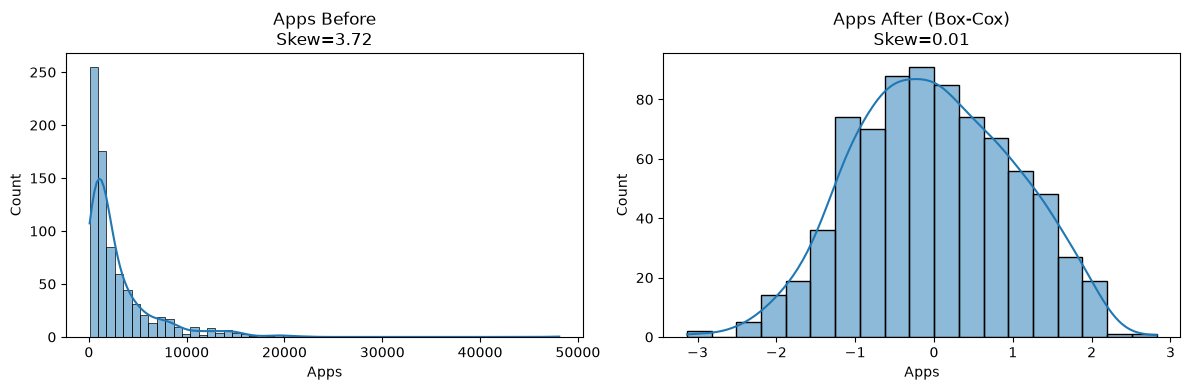

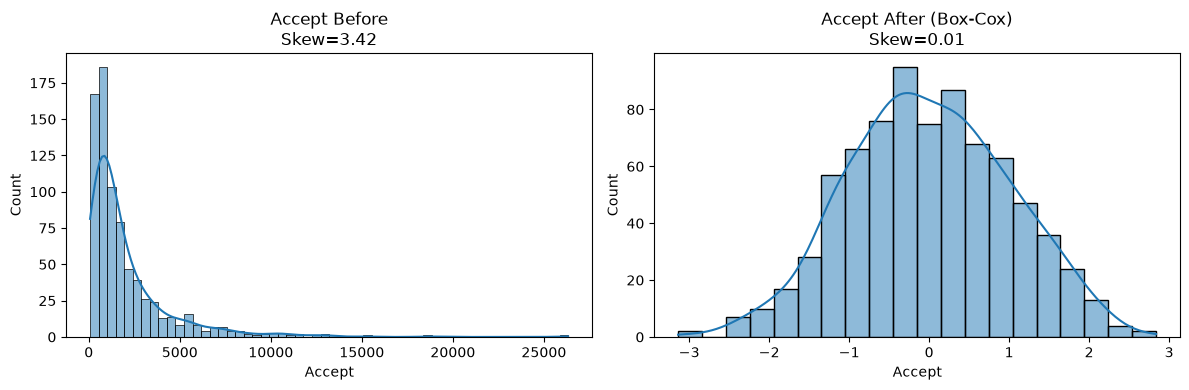

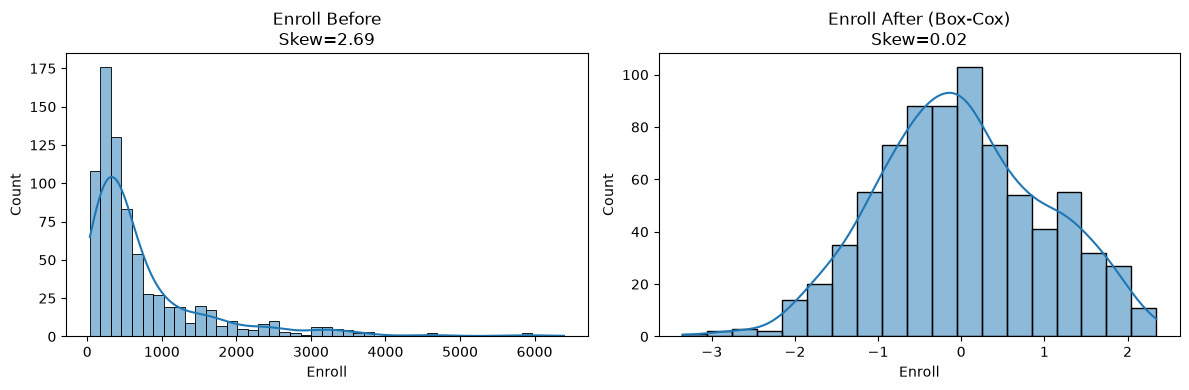

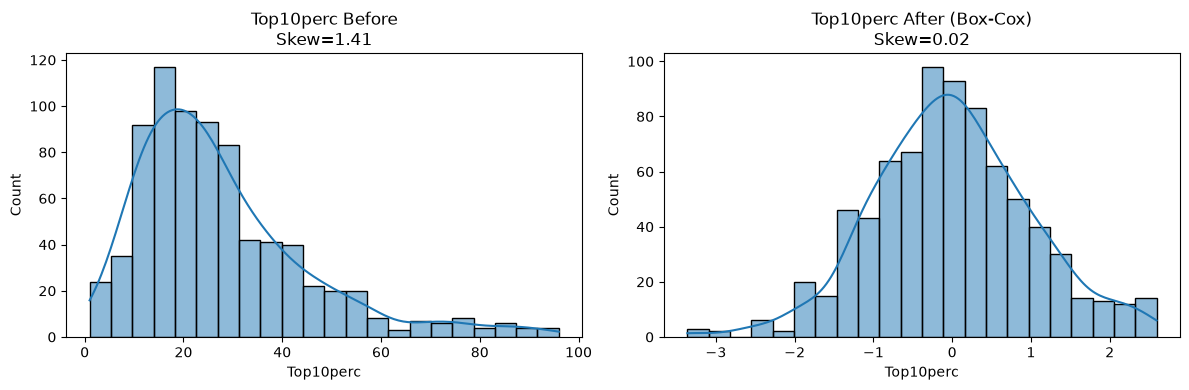

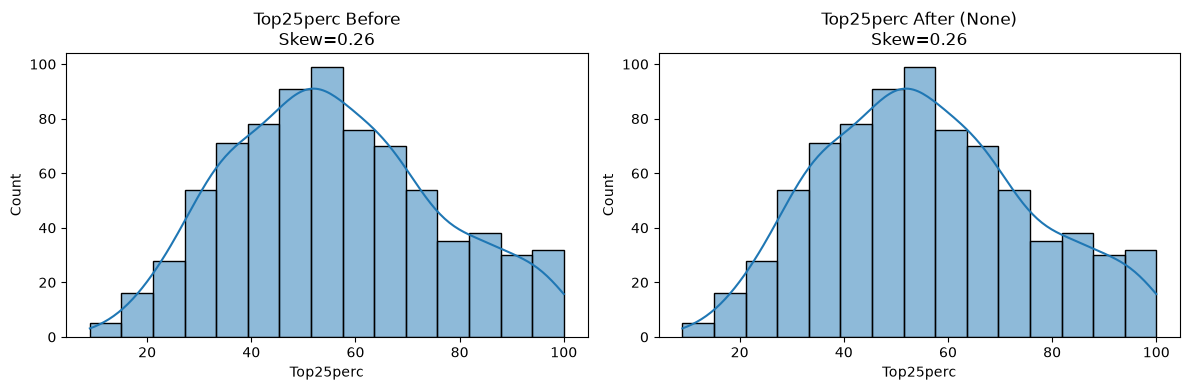

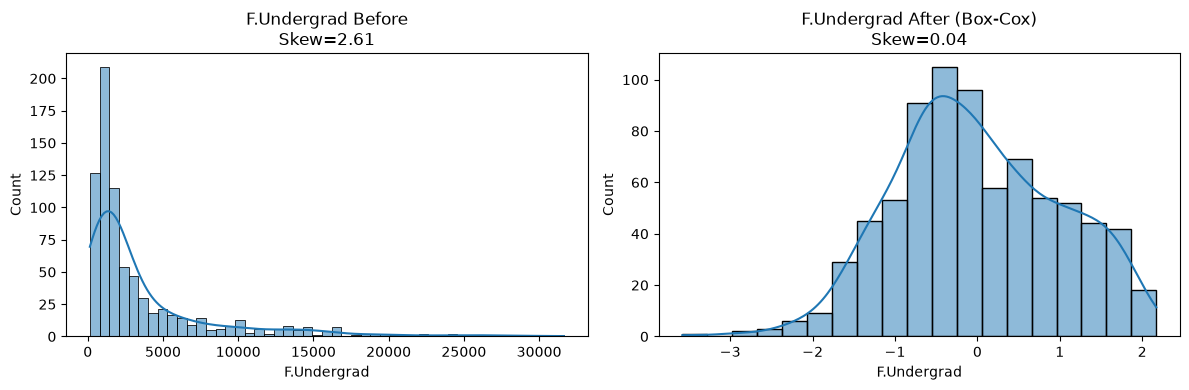

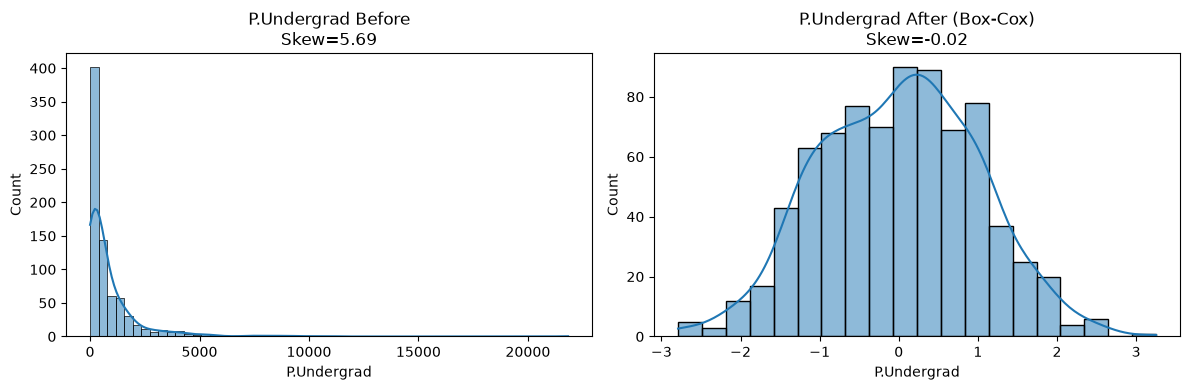

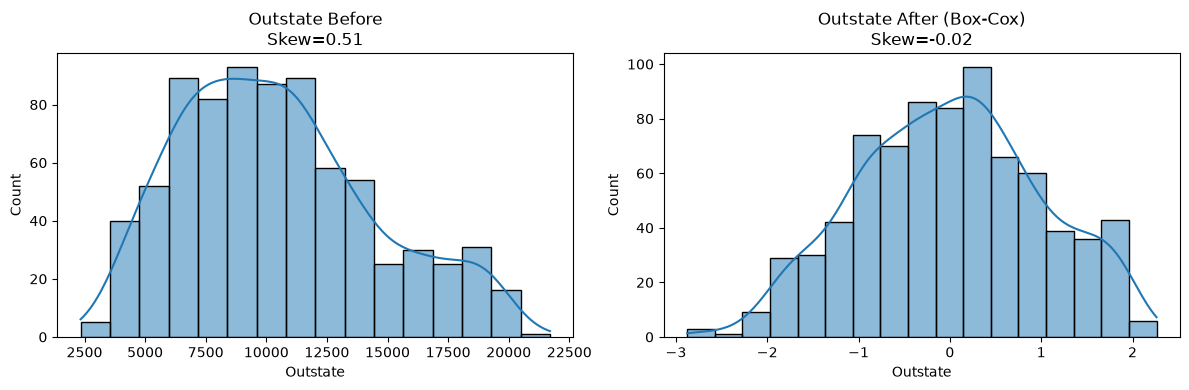

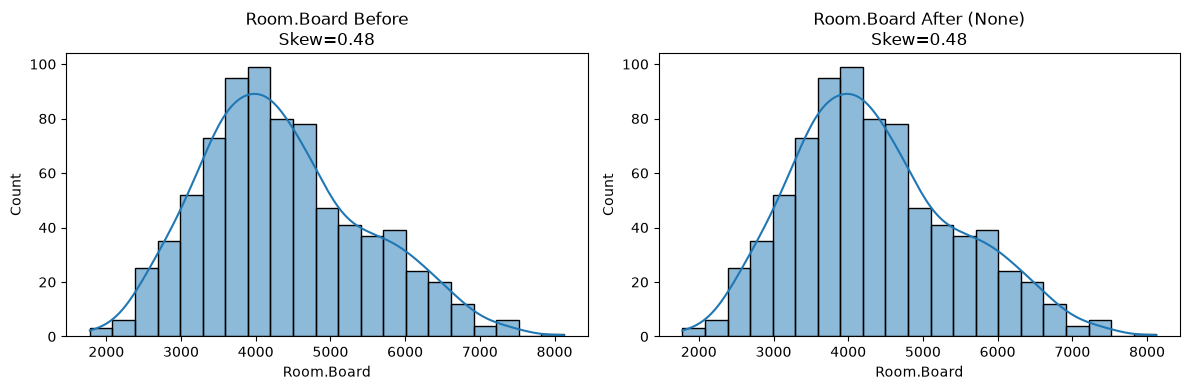

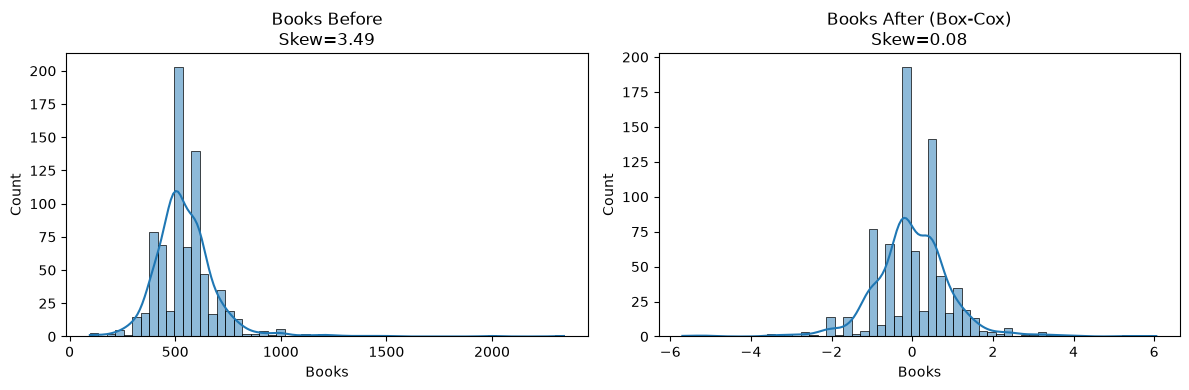

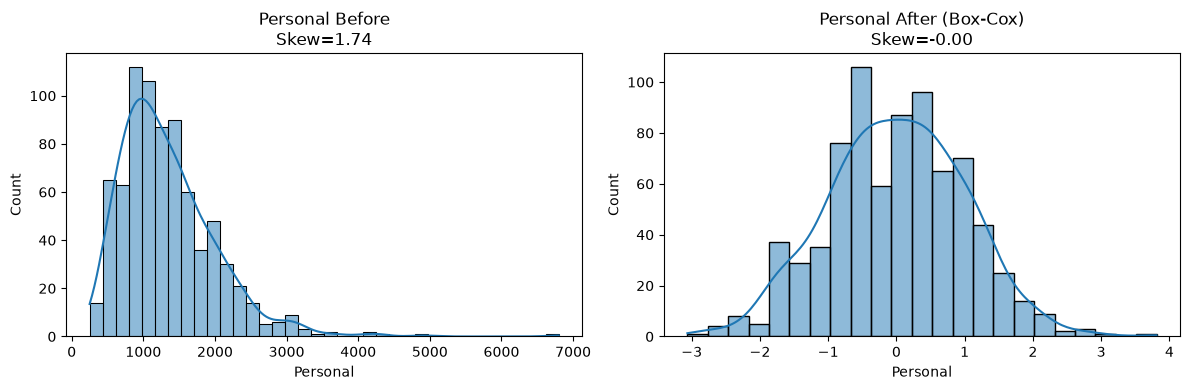

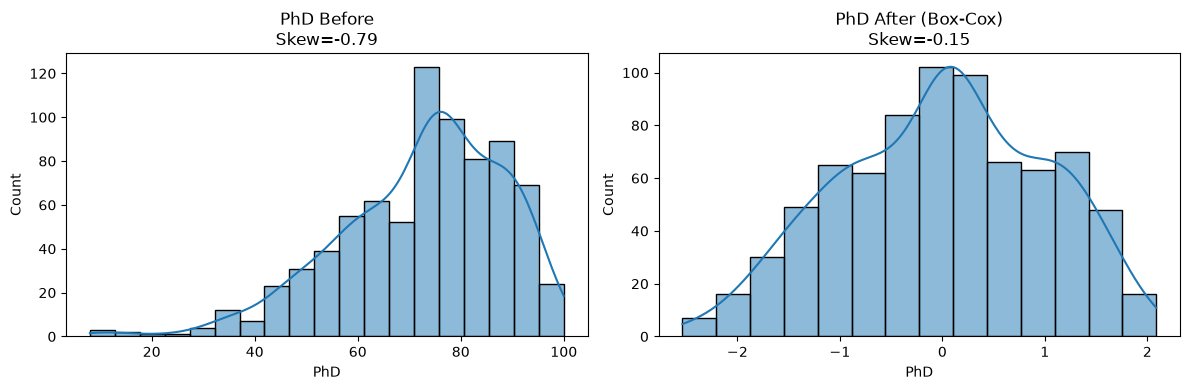

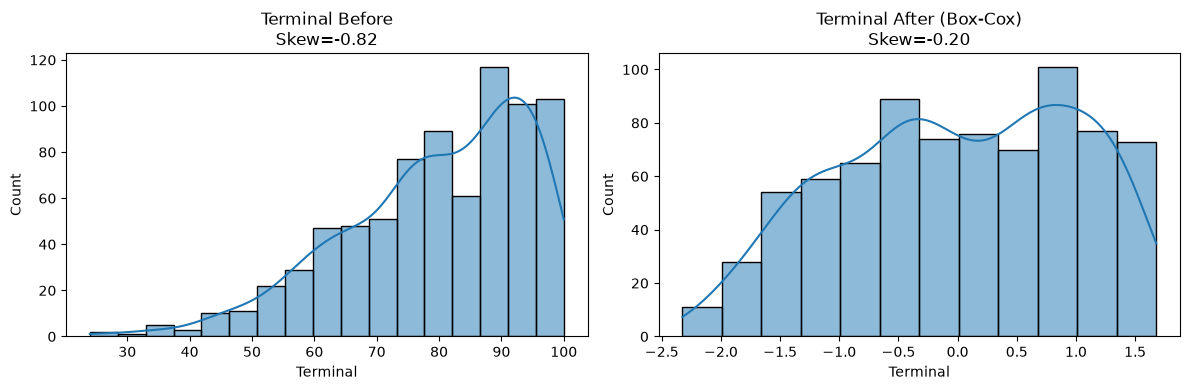

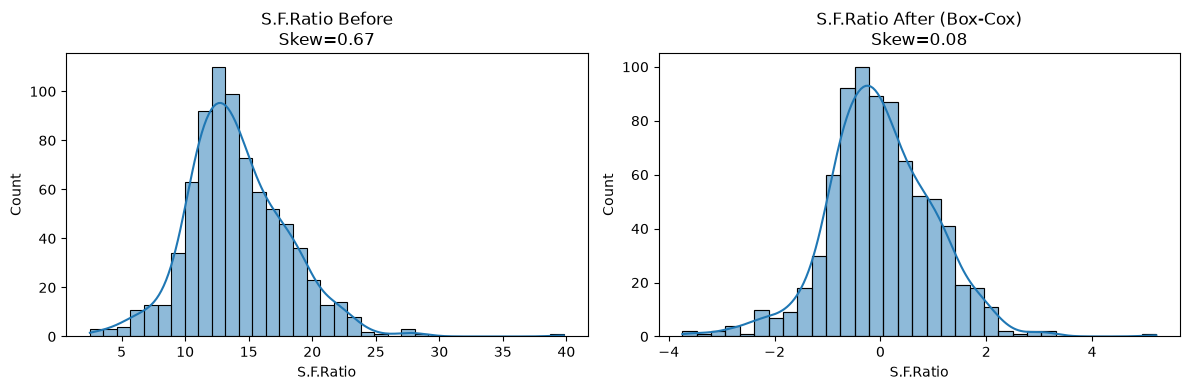

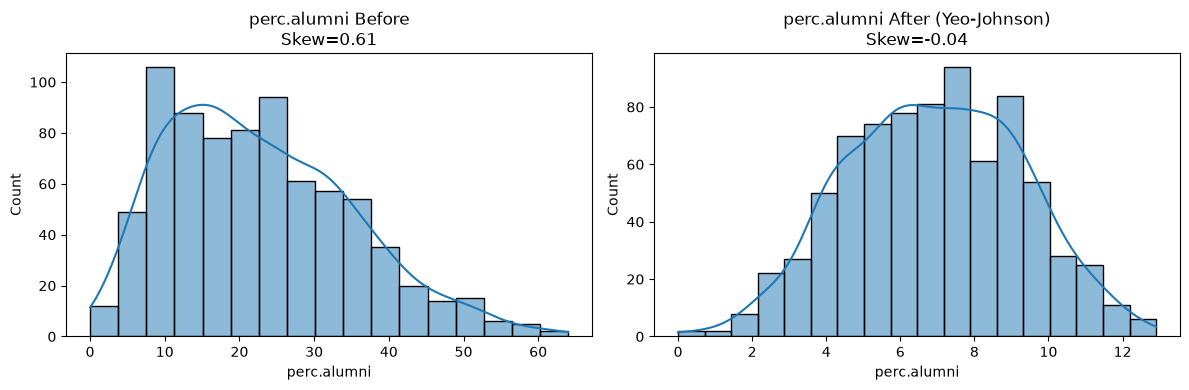

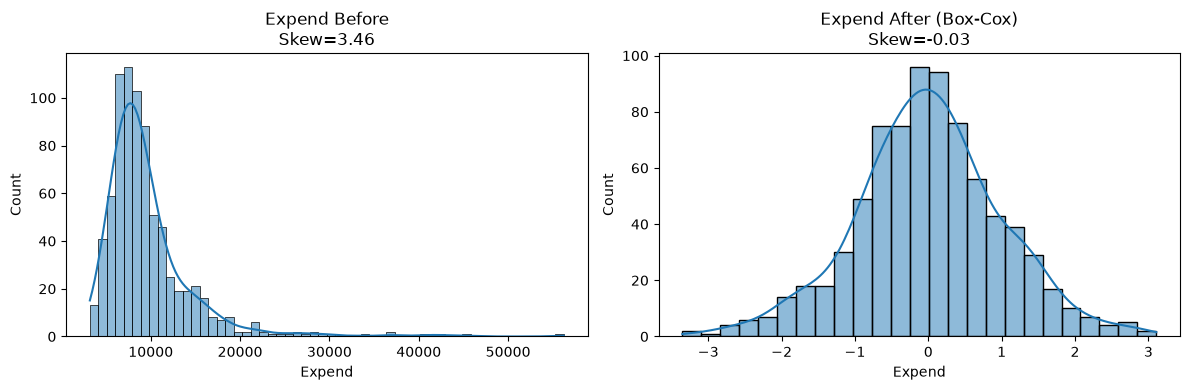

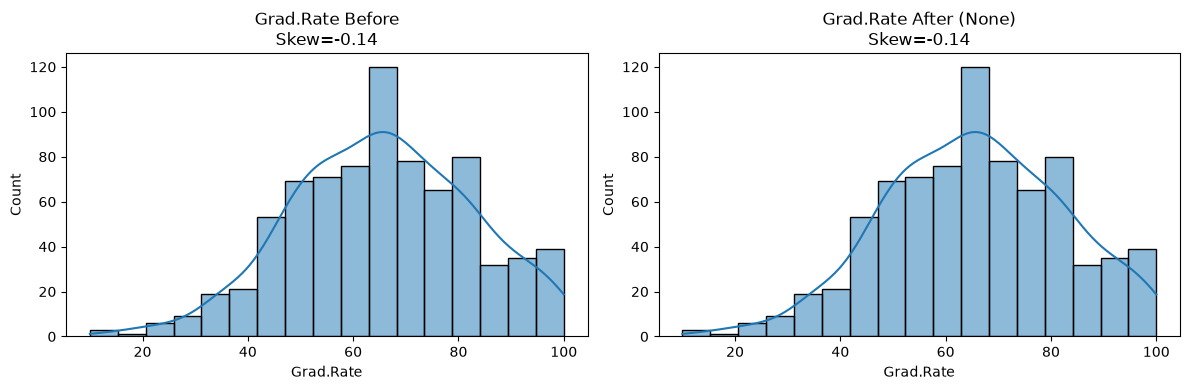

In [42]:
transformed_df = plot_transformations(df, skew_table)

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [44]:
# Your code here
skew_table = skew_calc(df)

skew_table

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
# Your code here

In [ ]:
# Your code here
transformed_df = plot_transformations(df, skew_table)

In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [45]:
# Your code here 
for _, row in skew_table.iterrows():

    col = row['Feature']
    transform = row['Recommended Transformation']

    if transform == 'None':
        continue

    if transform == 'Log Plus One':
        df[col + '_trans'] = np.log1p(df[col])

    elif transform == 'Box-Cox':
        transformer = PowerTransformer(method='box-cox', standardize=False)
        df[col + '_trans'] = transformer.fit_transform(df[[col]]).flatten()

    elif transform == 'Yeo-Johnson':
        transformer = PowerTransformer(method='yeo-johnson', standardize=False)
        df[col + '_trans'] = transformer.fit_transform(df[[col]]).flatten()

df.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,3.769302,8.713915,59.142209,9.288880,10.374877,2504.239962,34148.774234,7.965493,4.953607,1.828730
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,3.756515,10.316290,70.781897,10.448462,9.706972,427.169553,2801.807925,5.909038,5.900711,1.831689
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,3.568664,5.815935,68.600055,9.032160,9.276476,1433.028797,22055.928365,6.170678,8.505877,1.830396
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,3.401005,5.119856,72.157160,9.288880,8.798545,4333.028101,60412.083923,4.059557,9.568133,1.835020
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,3.202743,9.631371,59.483775,10.600468,9.706972,2953.457225,27695.561321,5.795125,1.435605,1.831929


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [46]:
# Your code here 
df['Accept_Rate'] = df['Accept'] / df['Apps']

df['Accept_Rate'] = (df['Accept'] / df['Apps']) * 100

df[['Accept_Rate']]

,Accept_Rate
0,74.216867
1,88.014639
2,76.820728
3,83.693046
4,75.647668
...,...
772,68.957670
773,92.138846
774,91.320935
775,22.914526


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [47]:
# Your code here 
df['Outstate_Tier'] = pd.cut(
    df['Outstate'],
    bins=3,
    labels=['Low', 'Medium', 'High'])

df[['Outstate', 'Outstate_Tier']].head()

,Outstate,Outstate_Tier
0,7440,Low
1,12280,Medium
2,11250,Medium
3,12960,Medium
4,7560,Low


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [48]:
# Your code here 
df['Outstate_Tier_Encoded'] = df['Outstate_Tier'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

df[['Outstate_Tier', 'Outstate_Tier_Encoded']].head()

,Outstate_Tier,Outstate_Tier_Encoded
0,Low,0
1,Medium,1
2,Medium,1
3,Medium,1
4,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [49]:
# Your code here 

df['Private_Encoded'] = df['Private'].map({
    'Yes': 1,
    'No': 0
})

df[['Private', 'Private_Encoded']].head()

,Private,Private_Encoded
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


In [50]:
df.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans,Accept_Rate,Outstate_Tier,Outstate_Tier_Encoded,Private_Encoded
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,10.374877,2504.239962,34148.774234,7.965493,4.953607,1.828730,74.216867,Low,0,1
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,9.706972,427.169553,2801.807925,5.909038,5.900711,1.831689,88.014639,Medium,1,1
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,9.276476,1433.028797,22055.928365,6.170678,8.505877,1.830396,76.820728,Medium,1,1
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,8.798545,4333.028101,60412.083923,4.059557,9.568133,1.835020,83.693046,Medium,1,1
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,9.706972,2953.457225,27695.561321,5.795125,1.435605,1.831929,75.647668,Low,0,1


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   College                777 non-null    str     
 1   Private                777 non-null    str     
 2   Apps                   777 non-null    int64   
 3   Accept                 777 non-null    int64   
 4   Enroll                 777 non-null    int64   
 5   Top10perc              777 non-null    int64   
 6   Top25perc              777 non-null    int64   
 7   F.Undergrad            777 non-null    int64   
 8   P.Undergrad            777 non-null    int64   
 9   Outstate               777 non-null    int64   
 10  Room.Board             777 non-null    int64   
 11  Books                  777 non-null    int64   
 12  Personal               777 non-null    int64   
 13  PhD                    777 non-null    float64 
 14  Terminal               777 non-null    int64   
 15  

## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [52]:
# Your code here
cols_to_scale =['Accept_trans','Enroll_trans','Top10perc_trans','F.Undergrad_trans','P.Undergrad_trans','Outstate_trans',
'Books_trans','Personal_trans','PhD_trans','Terminal_trans','S.F.Ratio_trans','perc.alumni_trans','Expend_trans','Outstate_Tier_Encoded', 'Accept_Rate']
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[cols_to_scale])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=[col + '_scaled' for col in cols_to_scale],
    index=df.index)

df = pd.concat([df, scaled_df], axis=1)

df.head()

DuplicateError: Expected unique column names, got:
- 'Accept_trans' 2 times
- 'Enroll_trans' 2 times
- 'Top10perc_trans' 2 times
- 'F.Undergrad_trans' 2 times
- 'P.Undergrad_trans' 2 times
- 'Outstate_trans' 2 times
- 'Books_trans' 2 times
- 'Personal_trans' 2 times
- 'PhD_trans' 2 times
- 'Terminal_trans' 2 times
- 'S.F.Ratio_trans' 2 times
- 'perc.alumni_trans' 2 times
- 'Expend_trans' 2 times

#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

In [ ]:
college_updated =college.copy()

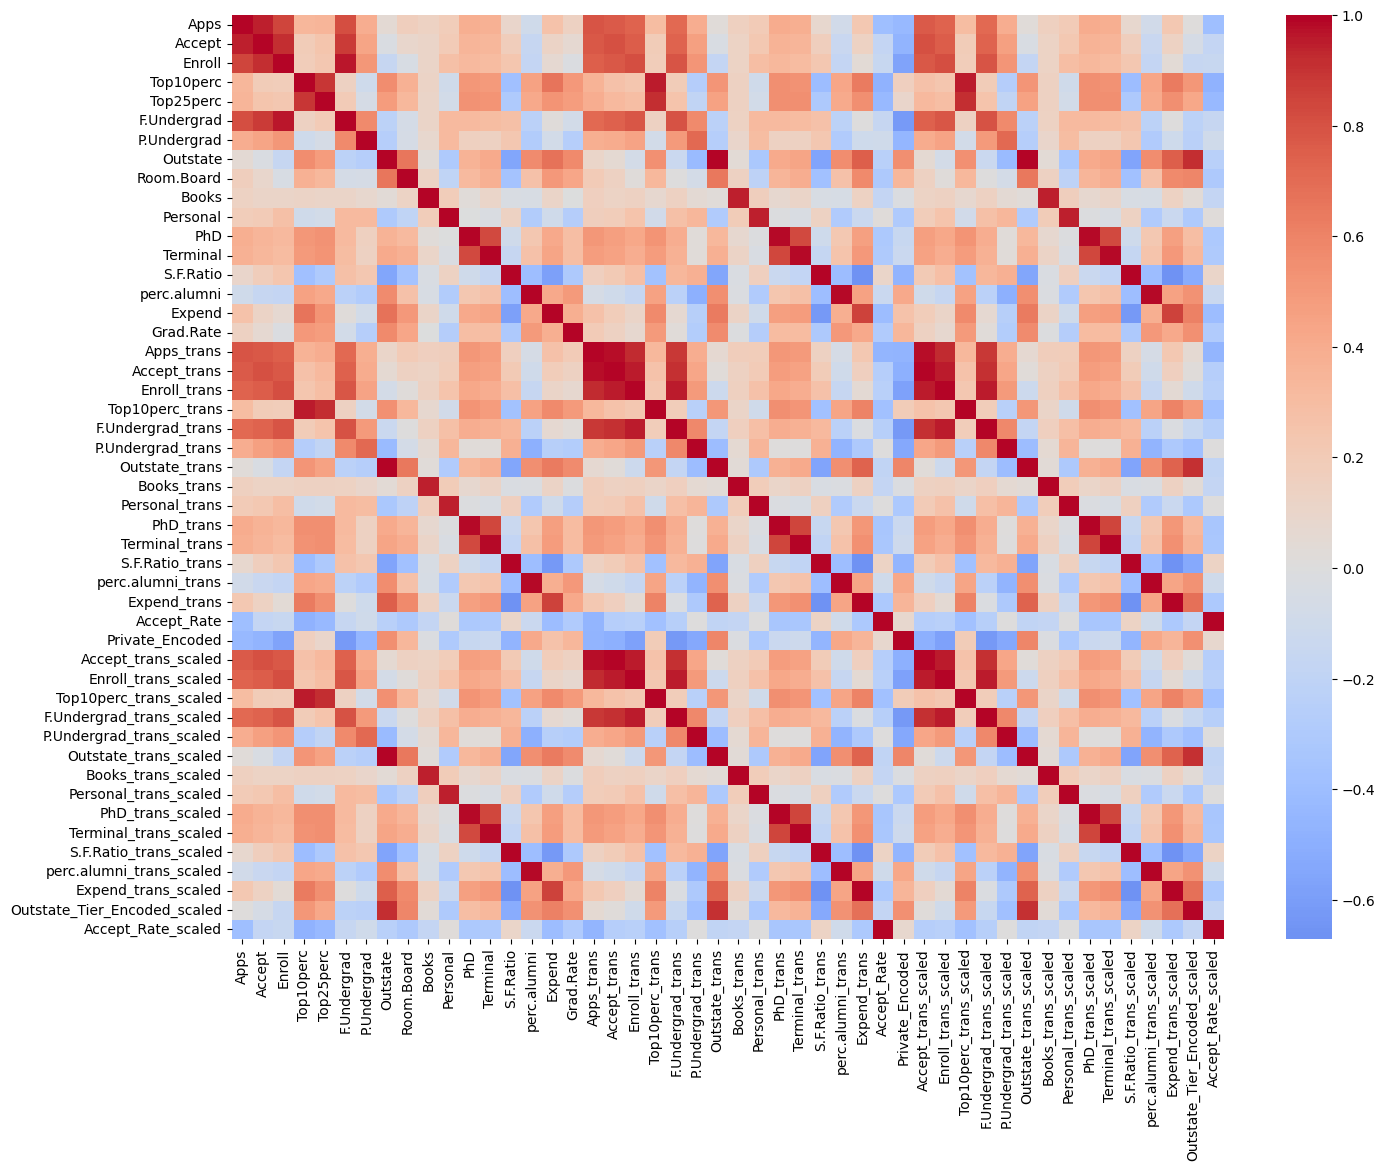

In [31]:
# Your code here 
plt.figure(figsize=(16,12))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm',
    center=0
)

plt.show()

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [32]:
# Your code here 


#### 15. Fit a linear regression using the raw predictors


In [33]:
untrans_predictors = []

# Your code here 

#### 16. Fit the same model using the log-transformed predictors

In [34]:
trans_predictors = []

# Your code here 

#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [35]:
# Your code here 

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [36]:
# Your code here 